# White-Box Lie Detection - Llama-3.1-70B-Instruct (Google Colab / A100)

Ce notebook reproduit l'experience white-box de lie detection dans un format **Google Colab** pour **Llama-3.1-70B-Instruct**.

**Base sur** [llm_lie_detection_black_vs_white_box](https://github.com/GeorgeVasile04/llm_lie_detection_black_vs_white_box) par GeorgeVasile04, avec adaptation Colab pour :
- la metrique **AUC (ROC AUC)**
- la selection du best layer en **4-fold cross-validation**
- le chargement du token Hugging Face depuis le secret Colab **`HF_TOKEN`**
- une verification explicite que le token a bien acces au repo officiel **`meta-llama/Llama-3.1-70B-Instruct`**

## Comment utiliser
1. Ouvre ce notebook dans Google Colab
2. Va dans **Runtime > Change runtime type > GPU**
3. Choisis un **A100 40GB**
4. Accepte la licence Meta sur Hugging Face : https://huggingface.co/meta-llama/Llama-3.1-70B-Instruct
5. Dans Colab, ajoute le secret **`HF_TOKEN`** avec ton token Hugging Face
6. Execute toutes les cellules dans l'ordre

| Modele | Params | VRAM (4-bit) | GPU requis |
|--------|--------|--------------|------------|
| Llama-3.1-70B-Instruct | 70B | ~38GB | A100 40GB |

## 1. Setup: GPU check + installations

In [39]:
# Verifier le GPU disponible
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_vram = props.total_memory / 1024**3
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {gpu_vram:.1f} GB")
    if gpu_vram < 35:
        print("=" * 50)
        print("  ATTENTION: Llama-3.1-70B-Instruct en 4-bit demande environ 38GB VRAM.")
        print(f"  Tu as seulement {gpu_vram:.0f}GB. Il faut un A100 40GB.")
        print("  Va dans Runtime > Change runtime type > A100")
        print("=" * 50)
else:
    print("PAS DE GPU! Va dans Runtime > Change runtime type > GPU (A100)")
    raise RuntimeError("GPU requis")

GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.3 GB


In [40]:
# Installer seulement la stack Hugging Face necessaire pour Colab
from pathlib import Path
import subprocess
import sys

DEPS_MARKER = Path('/content/.llm_lie_detection_deps_ready')
REQUIRED_PACKAGES = [
    'transformers==4.45.2',
    'accelerate==0.34.2',
    'bitsandbytes==0.45.5',
    'datasets==2.21.0',
    'huggingface_hub==0.24.7',
    'safetensors>=0.4.4',
]

if not DEPS_MARKER.exists():
    print('Installation des dependances Colab...')
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--upgrade-strategy',
        'only-if-needed',
        *REQUIRED_PACKAGES,
    ])
    DEPS_MARKER.touch()
    print('=' * 50)
    print('  Dependances installees.')
    print('  Le runtime va redemarrer une seule fois.')
    print('  Apres le restart, relance Runtime > Run all.')
    print('=' * 50)
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    print('Dependances deja installees dans cette session Colab.')

Dependances deja installees dans cette session Colab.


In [41]:
# Monter Google Drive pour sauvegarder les resultats
from google.colab import drive
drive.mount('/content/drive')

import os
RESULTS_DIR = '/content/drive/MyDrive/LLM_Lie_Detection_Results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Resultats sauvegardes dans: {RESULTS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resultats sauvegardes dans: /content/drive/MyDrive/LLM_Lie_Detection_Results


In [42]:
# Charger le token Hugging Face depuis Colab Secrets
import os
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get('HF_TOKEN')
if not HF_TOKEN:
    raise ValueError(
        "Secret Colab 'HF_TOKEN' introuvable. Ajoute-le dans le panneau Secrets puis relance cette cellule."
    )

os.environ['HF_TOKEN'] = HF_TOKEN
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_TOKEN
login(token=HF_TOKEN, add_to_git_credential=False)
print('HF_TOKEN charge depuis Colab Secrets.')

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful
HF_TOKEN charge depuis Colab Secrets.


## 2. Code principal

In [43]:
import gc
import json
import os
import pickle
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
from huggingface_hub import whoami

print("Imports OK")

Imports OK


In [44]:
#######################################################################
# CONFIGURATION
#######################################################################

MODEL_CONFIG = {
    "name": "Llama-3.1-70B-Instruct",
    "hf_id": "meta-llama/Llama-3.1-70B-Instruct",
    "num_params": 70.0,
    "quant": "4bit",
    "slug": "llama31_70b",
    "repo_source": "official",
}

# Memes datasets que les experiences locales (Pythia)
DATASETS_CONFIG = [
    {"name": "arc_easy",        "hf_id": "allenai/ai2_arc", "subset": "ARC-Easy",  "type": "arc"},
    {"name": "common_sense_qa", "hf_id": "tau/commonsense_qa", "subset": None,      "type": "csqa"},
    {"name": "boolq",           "hf_id": "google/boolq",    "subset": None,         "type": "boolq"},
    {"name": "imdb",            "hf_id": "stanfordnlp/imdb", "subset": None,         "type": "imdb"},
    {"name": "dbpedia_14",      "hf_id": "fancyzhx/dbpedia_14", "subset": None,     "type": "dbpedia"},
]

MAX_TRAIN = 100
MAX_VAL = 200
MAX_LENGTH = 256          # Plus stable sur Colab que 512 pour le 70B
LAYERS_SKIP = 2           # Extraire 1 couche sur 2
N_FOLDS = 4               # 4-fold CV pour best layer
SAVE_EVERY = 10           # Sauvegarde cache activations tous les N exemples
CLEAR_CACHE_EVERY = 5     # Purge CUDA periodique pendant l'extraction
LOAD_MODEL_PER_DATASET = True  # Plus lent, mais bien plus stable sur Colab

ACTIVATIONS_CACHE_PATH = Path(RESULTS_DIR) / f"activations_{MODEL_CONFIG['slug']}.pkl"
RESULTS_CSV_PATH = Path(RESULTS_DIR) / f"results_{MODEL_CONFIG['slug']}.csv"
CV_RESULTS_CSV_PATH = Path(RESULTS_DIR) / f"cv_results_{MODEL_CONFIG['slug']}.csv"
SUMMARY_JSON_PATH = Path(RESULTS_DIR) / f"summary_{MODEL_CONFIG['slug']}.json"

print(f"Modele cible: {MODEL_CONFIG['name']} ({MODEL_CONFIG['num_params']}B)")
print(f"Repo officiel: {MODEL_CONFIG['hf_id']}")
print(f"Datasets: {[d['name'] for d in DATASETS_CONFIG]}")
print(f"4-fold CV pour selection du best layer")
print(f"Metrique principale: AUC (ROC AUC)")
print(f"Max length: {MAX_LENGTH} tokens")
print(f"Cache activations: {ACTIVATIONS_CACHE_PATH}")
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"GPU VRAM: {vram_gb:.1f} GB")

Modele cible: Llama-3.1-70B-Instruct (70.0B)
Repo officiel: meta-llama/Llama-3.1-70B-Instruct
Datasets: ['arc_easy', 'common_sense_qa', 'boolq', 'imdb', 'dbpedia_14']
4-fold CV pour selection du best layer
Metrique principale: AUC (ROC AUC)
Max length: 256 tokens
Cache activations: /content/drive/MyDrive/LLM_Lie_Detection_Results/activations_llama31_70b.pkl
GPU VRAM: 79.3 GB


In [45]:
#######################################################################
# Dataset Loading - paires Vrai/Faux
#######################################################################

def load_binary_dataset(config):
    """Load a dataset and convert to True/False text statements."""
    ds_type = config["type"]
    samples = {"train": [], "validation": []}

    if ds_type == "arc":
        ds = load_dataset(config["hf_id"], config["subset"])
        for split_name, split_key in [("train", "train"), ("validation", "test")]:
            for row in ds[split_key]:
                q = row["question"]
                choices = row["choices"]["text"]
                labels = row["choices"]["label"]
                correct_idx = labels.index(row["answerKey"]) if row["answerKey"] in labels else 0
                correct = choices[correct_idx]
                wrong = choices[(correct_idx + 1) % len(choices)]
                group_id = q[:50]
                samples[split_name].append({"text": f"Question: {q}\nAnswer: {correct}\nIs this answer correct? Yes.", "label": True, "group_id": group_id})
                samples[split_name].append({"text": f"Question: {q}\nAnswer: {wrong}\nIs this answer correct? No.", "label": False, "group_id": group_id})

    elif ds_type == "csqa":
        ds = load_dataset(config["hf_id"])
        for split_name, split_key in [("train", "train"), ("validation", "validation")]:
            for row in ds[split_key]:
                q = row["question"]
                choices = row["choices"]["text"]
                labels = row["choices"]["label"]
                answer_key = row.get("answerKey", "A")
                correct_idx = labels.index(answer_key) if answer_key in labels else 0
                correct = choices[correct_idx]
                wrong = choices[(correct_idx + 1) % len(choices)]
                group_id = q[:50]
                samples[split_name].append({"text": f"Question: {q}\nAnswer: {correct}\nIs this answer correct? Yes.", "label": True, "group_id": group_id})
                samples[split_name].append({"text": f"Question: {q}\nAnswer: {wrong}\nIs this answer correct? No.", "label": False, "group_id": group_id})

    elif ds_type == "boolq":
        ds = load_dataset(config["hf_id"])
        for split_name in ["train", "validation"]:
            for row in ds[split_name]:
                answer = "Yes" if row["answer"] else "No"
                samples[split_name].append({"text": f"Passage: {row['passage'][:300]}\nQuestion: {row['question']}\nAnswer: {answer}", "label": row["answer"], "group_id": None})

    elif ds_type == "imdb":
        ds = load_dataset(config["hf_id"])
        for split_name, split_key in [("train", "train"), ("validation", "test")]:
            for row in ds[split_key]:
                sentiment = "positive" if row["label"] == 1 else "negative"
                samples[split_name].append({"text": f"Review: {row['text'][:400]}\nSentiment: {sentiment}", "label": row["label"] == 1, "group_id": None})

    elif ds_type == "dbpedia":
        ds = load_dataset(config["hf_id"])
        label_names = ds["train"].features["label"].names
        for split_name, split_key in [("train", "train"), ("validation", "test")]:
            for row in ds[split_key]:
                true_label = label_names[row["label"]]
                wrong_label = label_names[(row["label"] + 1) % len(label_names)]
                text_snippet = row["content"][:300]
                samples[split_name].append({"text": f"Text: {text_snippet}\nCategory: {true_label}", "label": True, "group_id": None})
                samples[split_name].append({"text": f"Text: {text_snippet}\nCategory: {wrong_label}", "label": False, "group_id": None})

    # Limit and shuffle
    for split in ["train", "validation"]:
        np.random.seed(42)
        np.random.shuffle(samples[split])
        limit = MAX_TRAIN if split == "train" else MAX_VAL
        samples[split] = samples[split][:limit]

    return samples

In [46]:
#######################################################################
# Model Loading with 4-bit quantization
#######################################################################

def validate_hf_model_access(model_config):
    """Fail early if the token/account cannot access the official Llama 3.1 70B repo."""
    hf_token = os.environ.get('HF_TOKEN')
    if not hf_token:
        raise ValueError("HF_TOKEN absent de l'environnement Colab.")

    account_info = whoami(token=hf_token)
    account_name = account_info.get('name') or account_info.get('email') or 'unknown'
    print(f"Compte Hugging Face detecte: {account_name}")
    print(f"Verification d'acces a {model_config['hf_id']}...")

    try:
        AutoConfig.from_pretrained(model_config['hf_id'], token=hf_token)
    except Exception as e:
        raise RuntimeError(
            f"Le token actuel n'a pas acces a {model_config['hf_id']}.\n"
            "Verifie que le secret Colab HF_TOKEN appartient bien au MEME compte Hugging Face que celui qui a ete accepte pour Llama 3.1.\n"
            "Si tu viens juste d'etre accepte, attends quelques minutes puis regenere un token Read et remets-le dans Colab Secrets.\n"
            f"Erreur initiale: {str(e)}"
        )

    print('Acces Hugging Face OK pour Llama-3.1-70B-Instruct.')


def load_model(model_config):
    """Load the official Llama 3.1 70B model for GPU inference."""
    hf_token = os.environ.get('HF_TOKEN')
    if not hf_token:
        raise ValueError("HF_TOKEN absent de l'environnement Colab.")

    hf_id = model_config['hf_id']
    print(f"Loading {hf_id}...")

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )
    model = AutoModelForCausalLM.from_pretrained(
        hf_id,
        token=hf_token,
        quantization_config=quant_config,
        device_map='auto',
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
        attn_implementation='sdpa',
    )

    tokenizer = AutoTokenizer.from_pretrained(
        hf_id,
        token=hf_token,
        use_fast=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'left'

    model.config.use_cache = False

    # Trouver les couches transformer automatiquement
    layers = None
    for attr_path in ['model.layers', 'transformer.h', 'gpt_neox.layers']:
        obj = model
        try:
            for part in attr_path.split('.'):
                obj = getattr(obj, part)
            layers = obj
            print(f"  Found {len(layers)} layers via {attr_path}")
            break
        except AttributeError:
            continue

    if layers is None:
        raise ValueError(f"Cannot find transformer layers in {hf_id}")

    model.eval()
    gc.collect()
    torch.cuda.empty_cache()
    vram_used = torch.cuda.memory_allocated() / 1024**3
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"  Source: {model_config['repo_source']}")
    print(f"  VRAM used: {vram_used:.1f} GB / {vram_total:.1f} GB")

    return model, tokenizer, layers

In [47]:
#######################################################################
# Activation Extraction
#######################################################################

def save_activation_cache(cache_path, all_activations):
    with open(cache_path, 'wb') as f:
        pickle.dump(all_activations, f)


def unload_model():
    gc.collect()
    torch.cuda.empty_cache()


@torch.inference_mode()
def extract_activations(model, tokenizer, layers, text, layers_skip=2):
    """Extract hidden-state activations at each layer for the last token."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    inputs = {k: v.to('cuda') for k, v in inputs.items()}

    layer_indices = list(range(0, len(layers), layers_skip))
    activations = {}
    hooks = []
    outputs = None

    for idx in layer_indices:
        name = f"h{idx}"
        def make_hook(layer_name):
            def hook_fn(module, input, output):
                hidden = output[0] if isinstance(output, tuple) else output
                activations[layer_name] = hidden[0, -1, :].detach().float().cpu().numpy()
            return hook_fn

        h = layers[idx].register_forward_hook(make_hook(name))
        hooks.append(h)

    try:
        outputs = model(**inputs, use_cache=False)
    finally:
        for h in hooks:
            h.remove()
        del outputs
        del inputs

    return activations

In [48]:
#######################################################################
# Probe Algorithms
#######################################################################

@dataclass
class ProbeResult:
    direction: np.ndarray

    def predict(self, activations):
        return activations @ self.direction


def train_dim(X, y):
    """Difference in Means."""
    true_mean = X[y].mean(axis=0)
    false_mean = X[~y].mean(axis=0)
    d = true_mean - false_mean
    d = d / (np.linalg.norm(d) + 1e-8)
    return ProbeResult(direction=d)


def train_lda(X, y):
    """Linear Discriminant Analysis."""
    try:
        lda = LinearDiscriminantAnalysis()
        lda.fit(X, y)
        d = lda.coef_[0]
        d = d / (np.linalg.norm(d) + 1e-8)
        return ProbeResult(direction=d)
    except Exception:
        return train_dim(X, y)


def train_lr(X, y):
    """Logistic Regression."""
    lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    lr.fit(X, y)
    d = lr.coef_[0]
    d = d / (np.linalg.norm(d) + 1e-8)
    return ProbeResult(direction=d)


def train_pca(X, y):
    """PCA - unsupervised."""
    pca = PCA(n_components=1)
    pca.fit(X)
    d = pca.components_[0]
    d = d / (np.linalg.norm(d) + 1e-8)
    return ProbeResult(direction=d)


def train_lat(X, y):
    """Linear Artificial Tomography."""
    np.random.seed(42)
    n = len(X)
    indices = np.random.permutation(n)
    half = n // 2
    diffs = X[indices[:half]] - X[indices[half:2*half]]
    pca = PCA(n_components=1)
    pca.fit(diffs)
    d = pca.components_[0]
    d = d / (np.linalg.norm(d) + 1e-8)
    return ProbeResult(direction=d)


PROBE_ALGORITHMS = {
    "DIM": train_dim,
    "LDA": train_lda,
    "LR": train_lr,
    "PCA": train_pca,
    "LAT": train_lat,
}

print(f"Probe algorithms: {list(PROBE_ALGORITHMS.keys())}")

Probe algorithms: ['DIM', 'LDA', 'LR', 'PCA', 'LAT']


In [49]:
#######################################################################
# Evaluation avec AUC + 4-fold CV pour best layer
#######################################################################

def compute_auc(probe, X, y):
    """Compute ROC AUC, trying both directions (like George's code)."""
    logits = probe.predict(X)
    if len(np.unique(y)) < 2:
        return 0.5
    auc_normal = roc_auc_score(y, logits)
    auc_flipped = roc_auc_score(y, -logits)
    return max(auc_normal, auc_flipped)


def compute_accuracy(probe, X, y):
    """Compute accuracy, trying both directions."""
    logits = probe.predict(X)
    preds = logits > 0
    acc = accuracy_score(y, preds)
    acc_flipped = accuracy_score(y, ~preds)
    return max(acc, acc_flipped)


def select_best_layer_cv(all_acts, layer_names, algo_name, algo_fn, n_splits=4):
    """
    4-fold CV pour selectionner le best layer.
    Si des group_id existent, on utilise StratifiedGroupKFold pour eviter le data leakage.
    """
    best_layer = layer_names[0]
    best_auc = -1.0

    for layer_name in layer_names:
        valid = [s for s in all_acts if layer_name in s["activations"]]
        if len(valid) < n_splits * 2:
            continue

        X = np.stack([s["activations"][layer_name] for s in valid]).astype(np.float32)
        y = np.array([s["label"] for s in valid], dtype=bool)
        group_ids = [s.get("group_id") for s in valid]

        use_group_cv = all(g is not None for g in group_ids) and len(set(group_ids)) >= n_splits
        if use_group_cv:
            splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
            split_iterator = splitter.split(X, y, groups=np.array(group_ids))
        else:
            splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            split_iterator = splitter.split(X, y)

        fold_aucs = []
        for train_idx, val_idx in split_iterator:
            X_tr, X_va = X[train_idx], X[val_idx]
            y_tr, y_va = y[train_idx], y[val_idx]

            try:
                probe = algo_fn(X_tr, y_tr)
                logits = probe.predict(X_va)
                if len(np.unique(y_va)) < 2:
                    continue
                auc = roc_auc_score(y_va, logits)
                auc_flip = roc_auc_score(y_va, -logits)
                fold_aucs.append(max(auc, auc_flip))
            except Exception:
                continue

        mean_auc = np.mean(fold_aucs) if fold_aucs else 0.0
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_layer = layer_name

    return best_layer, best_auc


print("Evaluation functions ready (AUC + 4-fold CV)")

Evaluation functions ready (AUC + 4-fold CV)


## 3. Lancer l'experience sur Llama-3.1-70B-Instruct

In [50]:
#######################################################################
# MAIN EXPERIMENT
#######################################################################

model_name = MODEL_CONFIG["name"]
num_params = MODEL_CONFIG["num_params"]

print(f"{'='*60}")
print(f"  MODEL: {model_name} ({num_params}B params)")
print(f"  Metrique: AUC (ROC AUC)")
print(f"  Best layer: 4-fold CV")
print(f"  Started: {time.strftime('%H:%M:%S')}")
print(f"{'='*60}")

model_dir = Path(RESULTS_DIR) / model_name
model_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
model = tokenizer = layers = None

# ---- Check access BEFORE downloading datasets ----
validate_hf_model_access(MODEL_CONFIG)
print(f"Repo charge: {MODEL_CONFIG['hf_id']}")
print(f"Source repo: {MODEL_CONFIG['repo_source']}")

# ---- Load cached activations if available ----
if ACTIVATIONS_CACHE_PATH.exists():
    print(f"\nLoading cached activations from {ACTIVATIONS_CACHE_PATH}...")
    with open(ACTIVATIONS_CACHE_PATH, 'rb') as f:
        all_activations = pickle.load(f)
else:
    all_activations = {}

# ---- Identify datasets still missing or incomplete ----
datasets_to_extract = []
for ds_config in DATASETS_CONFIG:
    ds_name = ds_config['name']
    cached_ds = all_activations.get(ds_name, {'train': [], 'validation': []})
    if len(cached_ds.get('train', [])) >= MAX_TRAIN and len(cached_ds.get('validation', [])) >= MAX_VAL:
        continue
    datasets_to_extract.append(ds_config)

num_layers = None

for ds_config in datasets_to_extract:
    ds_name = ds_config['name']
    print(f"\n--- Dataset: {ds_name} ---")
    dataset = load_binary_dataset(ds_config)
    print(f"  Train cible: {len(dataset['train'])}, Val cible: {len(dataset['validation'])}")

    ds_activations = all_activations.get(ds_name, {'train': [], 'validation': []})

    if LOAD_MODEL_PER_DATASET:
        model, tokenizer, layers = load_model(MODEL_CONFIG)
        num_layers = len(layers)

    for split in ['train', 'validation']:
        target_samples = dataset[split]
        start_idx = len(ds_activations.get(split, []))
        if start_idx >= len(target_samples):
            print(f"  {split}: deja en cache ({start_idx}/{len(target_samples)})")
            continue

        print(f"  Extracting {split} a partir de {start_idx}/{len(target_samples)}...")
        errors = 0

        if not LOAD_MODEL_PER_DATASET and split == 'train' and start_idx == 0 and num_layers is None:
            model, tokenizer, layers = load_model(MODEL_CONFIG)
            num_layers = len(layers)

        progress = tqdm(range(start_idx, len(target_samples)), desc=f"    {split}")
        for sample_idx in progress:
            sample = target_samples[sample_idx]
            try:
                acts = extract_activations(model, tokenizer, layers, sample['text'], LAYERS_SKIP)
                ds_activations.setdefault(split, []).append({
                    'activations': acts,
                    'label': sample['label'],
                    'group_id': sample.get('group_id'),
                })

                processed_now = len(ds_activations[split]) - start_idx
                if processed_now % SAVE_EVERY == 0:
                    all_activations[ds_name] = ds_activations
                    save_activation_cache(ACTIVATIONS_CACHE_PATH, all_activations)
                    progress.set_postfix(saved=len(ds_activations[split]))

                if processed_now % CLEAR_CACHE_EVERY == 0:
                    gc.collect()
                    torch.cuda.empty_cache()

            except torch.cuda.OutOfMemoryError:
                all_activations[ds_name] = ds_activations
                save_activation_cache(ACTIVATIONS_CACHE_PATH, all_activations)
                raise RuntimeError(
                    f"OOM CUDA pendant {ds_name}/{split} a l'index {sample_idx}. "
                    "Le cache partiel est sauve. Relance la cellule pour reprendre."
                )
            except Exception as e:
                errors += 1
                if errors <= 3:
                    print(f"    Warning: {e}")
                gc.collect()
                torch.cuda.empty_cache()
                continue

        all_activations[ds_name] = ds_activations
        save_activation_cache(ACTIVATIONS_CACHE_PATH, all_activations)
        print(f"  {split}: {len(ds_activations[split])}/{len(target_samples)} en cache")
        if errors > 0:
            print(f"    ({errors} erreurs ignorees)")

    if LOAD_MODEL_PER_DATASET:
        del model, tokenizer, layers
        model = tokenizer = layers = None
        unload_model()
        vram_after = torch.cuda.memory_allocated() / 1024**3
        print(f"  Modele decharge. VRAM: {vram_after:.1f} GB")

if not datasets_to_extract:
    print("\nToutes les activations sont deja en cache. Aucune inference modele a refaire.")

# ---- Recover layer info from cached activations if needed ----
first_ds = next(ds for ds, content in all_activations.items() if content.get('train'))
first_samples = all_activations[first_ds]['train']
layer_names = sorted(first_samples[0]['activations'].keys(), key=lambda x: int(x[1:]))
if num_layers is None:
    num_layers = max(int(layer_name[1:]) for layer_name in layer_names) + 1
print(f"Layers disponibles: {layer_names}")

# ---- Train probes with 4-fold CV for best layer ----
print(f"\n{'='*60}")
print(f"  TRAINING PROBES (4-fold CV for best layer)")
print(f"{'='*60}")

all_results = []
cv_results = []

for train_ds in all_activations:
    train_samples = all_activations[train_ds]['train']
    print(f"\n--- Train dataset: {train_ds} ---")

    for algo_name, algo_fn in PROBE_ALGORITHMS.items():
        best_layer, cv_auc = select_best_layer_cv(
            train_samples, layer_names, algo_name, algo_fn, n_splits=N_FOLDS
        )
        best_layer_idx = int(best_layer[1:])
        print(f"  {algo_name}: best layer = {best_layer_idx} (CV AUC = {cv_auc:.3f})")

        cv_results.append({
            'train_dataset': train_ds,
            'algorithm': algo_name,
            'best_layer': best_layer_idx,
            'cv_auc': cv_auc,
        })

        valid_train = [s for s in train_samples if best_layer in s['activations']]
        if len(valid_train) < 10:
            continue
        X_train = np.stack([s['activations'][best_layer] for s in valid_train]).astype(np.float32)
        y_train = np.array([s['label'] for s in valid_train], dtype=bool)

        try:
            probe = algo_fn(X_train, y_train)
        except Exception:
            continue

        for eval_ds in all_activations:
            val_samples = all_activations[eval_ds]['validation']
            valid_val = [s for s in val_samples if best_layer in s['activations']]
            if len(valid_val) < 10:
                continue
            X_val = np.stack([s['activations'][best_layer] for s in valid_val]).astype(np.float32)
            y_val = np.array([s['label'] for s in valid_val], dtype=bool)

            try:
                auc = compute_auc(probe, X_val, y_val)
                acc = compute_accuracy(probe, X_val, y_val)
            except Exception:
                continue

            all_results.append({
                'model': model_name,
                'loaded_hf_id': MODEL_CONFIG['hf_id'],
                'repo_source': MODEL_CONFIG['repo_source'],
                'num_params': num_params,
                'train_dataset': train_ds,
                'eval_dataset': eval_ds,
                'algorithm': algo_name,
                'best_layer': best_layer_idx,
                'num_layers': num_layers,
                'auc': auc,
                'accuracy': acc,
                'cv_auc': cv_auc,
                'in_distribution': train_ds == eval_ds,
            })

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"  DONE in {elapsed/60:.1f} min")
print(f"  {len(all_results)} results")
print(f"{'='*60}")

# Save results
df = pd.DataFrame(all_results)
df.to_csv(RESULTS_CSV_PATH, index=False)

df_cv = pd.DataFrame(cv_results)
df_cv.to_csv(CV_RESULTS_CSV_PATH, index=False)

print(f"\nSaved to {RESULTS_CSV_PATH}")

  MODEL: Llama-3.1-70B-Instruct (70.0B params)
  Metrique: AUC (ROC AUC)
  Best layer: 4-fold CV
  Started: 18:03:29
Compte Hugging Face detecte: kooshari
Verification d'acces a meta-llama/Llama-3.1-70B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

Acces Hugging Face OK pour Llama-3.1-70B-Instruct.
Repo charge: meta-llama/Llama-3.1-70B-Instruct
Source repo: official

--- Dataset: arc_easy ---
  Train cible: 100, Val cible: 200
Loading meta-llama/Llama-3.1-70B-Instruct...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00030.safetensors:   0%|          | 0.00/4.58G [00:00<?, ?B/s]

...

  Found 80 layers via model.layers
  Source: official
  VRAM used: 36.8 GB / 79.3 GB
  Extracting train a partir de 0/100...


    train:   0%|          | 0/100 [00:00<?, ?it/s]

  train: 100/100 en cache
  Extracting validation a partir de 0/200...


    validation:   0%|          | 0/200 [00:00<?, ?it/s]

  validation: 200/200 en cache
  Modele decharge. VRAM: 0.0 GB
Layers disponibles: ['h0', 'h2', 'h4', 'h6', 'h8', 'h10', 'h12', 'h14', 'h16', 'h18', 'h20', 'h22', 'h24', 'h26', 'h28', 'h30', 'h32', 'h34', 'h36', 'h38', 'h40', 'h42', 'h44', 'h46', 'h48', 'h50', 'h52', 'h54', 'h56', 'h58', 'h60', 'h62', 'h64', 'h66', 'h68', 'h70', 'h72', 'h74', 'h76', 'h78']

  TRAINING PROBES (4-fold CV for best layer)

--- Train dataset: arc_easy ---
  DIM: best layer = 0 (CV AUC = 1.000)
  LDA: best layer = 0 (CV AUC = 1.000)
  LR: best layer = 0 (CV AUC = 1.000)
  PCA: best layer = 0 (CV AUC = 1.000)
  LAT: best layer = 0 (CV AUC = 1.000)

--- Train dataset: common_sense_qa ---
  DIM: best layer = 0 (CV AUC = 1.000)
  LDA: best layer = 0 (CV AUC = 1.000)
  LR: best layer = 0 (CV AUC = 1.000)
  PCA: best layer = 0 (CV AUC = 1.000)
  LAT: best layer = 0 (CV AUC = 1.000)

--- Train dataset: boolq ---
  DIM: best layer = 0 (CV AUC = 1.000)
  LDA: best layer = 0 (CV AUC = 1.000)
  LR: best layer = 0 (CV A

## 4. Resultats: AUC par algorithme et dataset

In [51]:
# Charger les resultats
df = pd.read_csv(RESULTS_CSV_PATH)
df_cv = pd.read_csv(CV_RESULTS_CSV_PATH)

print(f"Total: {len(df)} results")
print(f"Modele: {model_name} ({num_params}B params)")

# ---- Tableau recapitulatif AUC ----
in_dist = df[df['in_distribution'] == True]
print(f"\n{'='*60}")
print(f"  RESULTATS AUC - {model_name}")
print(f"{'='*60}")

# AUC par algorithme (in-distribution)
print("\n--- AUC par algorithme (in-distribution, moyenne sur datasets) ---")
algo_auc = in_dist.groupby('algorithm')['auc'].mean().sort_values(ascending=False)
for algo, auc in algo_auc.items():
    print(f"  {algo:6s}: AUC = {auc:.3f}")

# AUC par dataset (in-distribution, meilleur algo)
print("\n--- AUC par dataset (in-distribution, meilleur algo) ---")
for ds in in_dist['train_dataset'].unique():
    ds_data = in_dist[in_dist['train_dataset'] == ds]
    best_row = ds_data.loc[ds_data['auc'].idxmax()]
    print(f"  {ds:20s}: AUC = {best_row['auc']:.3f} (algo={best_row['algorithm']}, layer={int(best_row['best_layer'])})")

# AUC globale
print(f"\n  AUC GLOBALE (in-dist): {in_dist['auc'].mean():.3f}")
print(f"  Meilleur algo global: {algo_auc.index[0]} (AUC={algo_auc.iloc[0]:.3f})")

# 4-fold CV summary
print(f"\n--- 4-fold CV: best layer par algo/dataset ---")
print(df_cv.to_string(index=False))

Total: 125 results
Modele: Llama-3.1-70B-Instruct (70.0B params)

  RESULTATS AUC - Llama-3.1-70B-Instruct

--- AUC par algorithme (in-distribution, moyenne sur datasets) ---
  LR    : AUC = 0.999
  LDA   : AUC = 0.999
  DIM   : AUC = 0.997
  PCA   : AUC = 0.919
  LAT   : AUC = 0.907

--- AUC par dataset (in-distribution, meilleur algo) ---
  arc_easy            : AUC = 1.000 (algo=DIM, layer=0)
  common_sense_qa     : AUC = 1.000 (algo=DIM, layer=0)
  boolq               : AUC = 1.000 (algo=DIM, layer=0)
  imdb                : AUC = 1.000 (algo=DIM, layer=0)
  dbpedia_14          : AUC = 0.997 (algo=LR, layer=32)

  AUC GLOBALE (in-dist): 0.964
  Meilleur algo global: LR (AUC=0.999)

--- 4-fold CV: best layer par algo/dataset ---
  train_dataset algorithm  best_layer   cv_auc
       arc_easy       DIM           0 1.000000
       arc_easy       LDA           0 1.000000
       arc_easy        LR           0 1.000000
       arc_easy       PCA           0 1.000000
       arc_easy       L

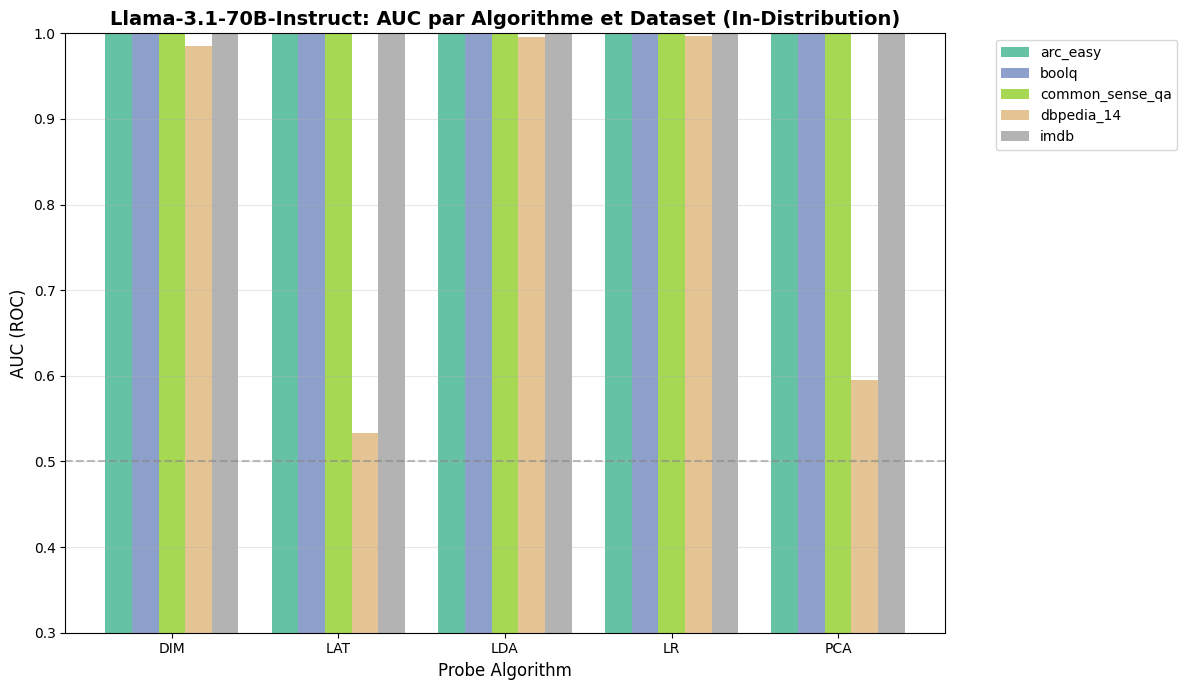

In [52]:
# Graphe 1: AUC par algorithme (in-distribution)
in_dist = df[df['in_distribution'] == True]
datasets = sorted(in_dist['train_dataset'].unique())
algorithms = sorted(in_dist['algorithm'].unique())
n_ds = len(datasets)
x = np.arange(len(algorithms))
width = 0.8 / max(n_ds, 1)
colors = plt.cm.Set2(np.linspace(0, 1, n_ds))

fig, ax = plt.subplots(figsize=(12, 7))
for i, ds in enumerate(datasets):
    ds_data = in_dist[in_dist['train_dataset'] == ds]
    algo_auc = ds_data.groupby('algorithm')['auc'].mean()
    vals = [algo_auc.get(a, 0.5) for a in algorithms]
    ax.bar(x + i * width, vals, width, label=ds, color=colors[i])

ax.set_xlabel('Probe Algorithm', fontsize=12)
ax.set_ylabel('AUC (ROC)', fontsize=12)
ax.set_title(f'{model_name}: AUC par Algorithme et Dataset (In-Distribution)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (n_ds - 1) / 2)
ax.set_xticklabels(algorithms)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0.3, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/{MODEL_CONFIG['slug']}_auc_by_algorithm.png", dpi=150)
plt.show()

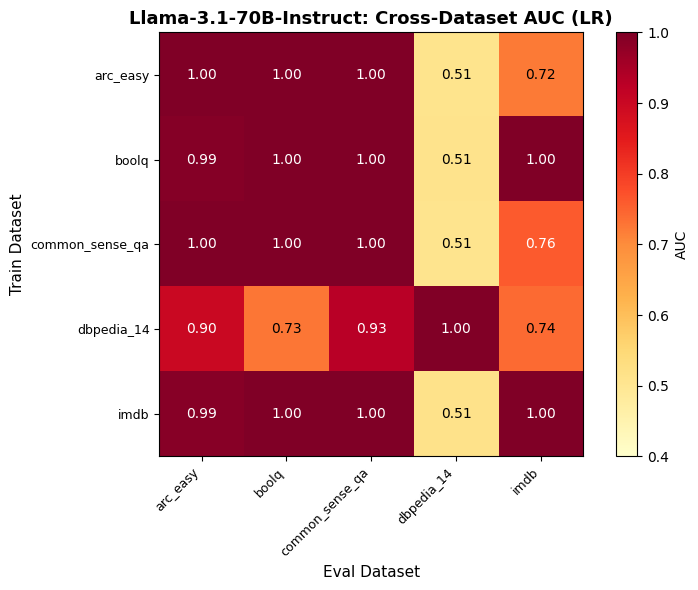

In [53]:
# Graphe 2: Matrice de generalisation AUC (cross-dataset)
best_algo = in_dist.groupby('algorithm')['auc'].mean().idxmax()
best_algo_data = df[df['algorithm'] == best_algo]

matrix = best_algo_data.groupby(['train_dataset', 'eval_dataset'])['auc'].mean().reset_index()
pivot = matrix.pivot(index='train_dataset', columns='eval_dataset', values='auc')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if val > 0.75 else 'black')
ax.set_xlabel('Eval Dataset', fontsize=11)
ax.set_ylabel('Train Dataset', fontsize=11)
ax.set_title(f'{model_name}: Cross-Dataset AUC ({best_algo})', fontweight='bold', fontsize=13)
fig.colorbar(im, label='AUC')
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/{MODEL_CONFIG['slug']}_generalization_matrix.png", dpi=150)
plt.show()

Generating layer-wise CV AUC plot for best algo (LR)...


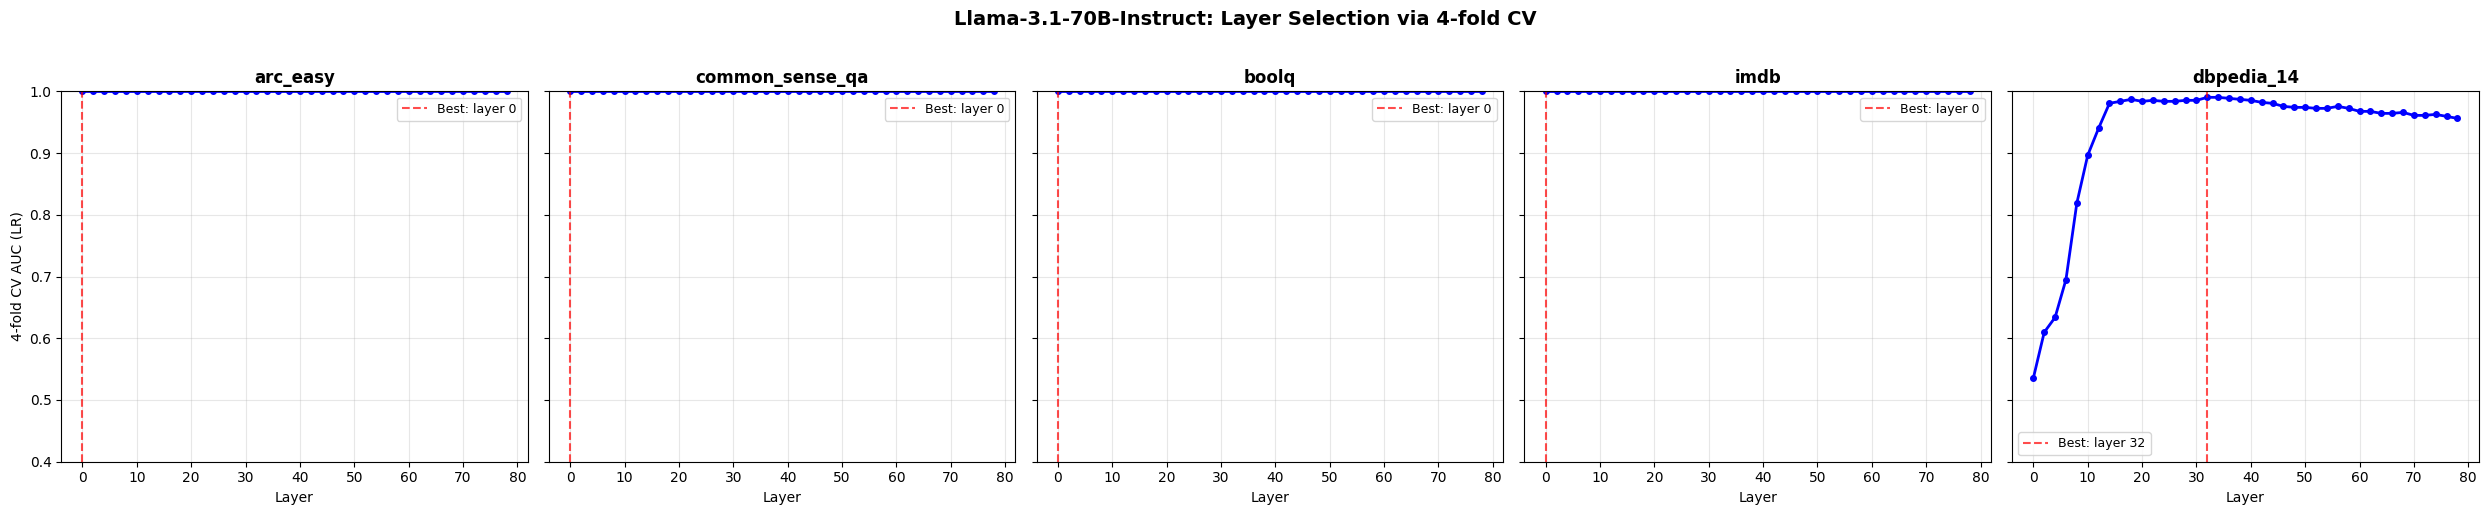

In [54]:
# Graphe 3: 4-fold CV AUC par layer (pour visualiser le choix du best layer)
# On refait le CV pour TOUTES les layers pour le meilleur algo, pour le graphe
print(f"Generating layer-wise CV AUC plot for best algo ({best_algo})...")

algo_fn = PROBE_ALGORITHMS[best_algo]

fig, axes = plt.subplots(1, len(DATASETS_CONFIG), figsize=(5 * len(DATASETS_CONFIG), 5), sharey=True)
if len(DATASETS_CONFIG) == 1:
    axes = [axes]

for ax, ds_name in zip(axes, [d['name'] for d in DATASETS_CONFIG]):
    if ds_name not in all_activations:
        continue
    train_samples = all_activations[ds_name]["train"]

    layer_aucs = {}
    for layer_name in layer_names:
        valid = [s for s in train_samples if layer_name in s["activations"]]
        if len(valid) < N_FOLDS * 2:
            continue

        X = np.stack([s["activations"][layer_name] for s in valid]).astype(np.float32)
        y = np.array([s["label"] for s in valid], dtype=bool)
        group_ids = [s.get("group_id") for s in valid]

        use_group_cv = all(g is not None for g in group_ids) and len(set(group_ids)) >= N_FOLDS
        if use_group_cv:
            splitter = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
            split_iterator = splitter.split(X, y, groups=np.array(group_ids))
        else:
            splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
            split_iterator = splitter.split(X, y)

        fold_aucs = []
        for train_idx, val_idx in split_iterator:
            try:
                probe = algo_fn(X[train_idx], y[train_idx])
                logits = probe.predict(X[val_idx])
                auc = roc_auc_score(y[val_idx], logits)
                auc_flip = roc_auc_score(y[val_idx], -logits)
                fold_aucs.append(max(auc, auc_flip))
            except Exception:
                continue
        if fold_aucs:
            layer_aucs[int(layer_name[1:])] = np.mean(fold_aucs)

    if layer_aucs:
        layers_sorted = sorted(layer_aucs.keys())
        aucs_sorted = [layer_aucs[l] for l in layers_sorted]
        best_l = max(layer_aucs, key=layer_aucs.get)
        ax.plot(layers_sorted, aucs_sorted, 'b-o', markersize=4, linewidth=2)
        ax.axvline(x=best_l, color='red', linestyle='--', alpha=0.7, label=f'Best: layer {best_l}')
        ax.legend(fontsize=9)

    ax.set_title(ds_name, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(f'4-fold CV AUC ({best_algo})')
fig.suptitle(f'{model_name}: Layer Selection via 4-fold CV', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/{MODEL_CONFIG['slug']}_layer_cv_auc.png", dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Tableau final: tout ensemble
print(f"\n{'='*60}")
print(f"  RESUME FINAL - {model_name} ({num_params}B)")
print(f"{'='*60}")
print(f"  Repo reellement charge: {MODEL_CONFIG['hf_id']}")
print(f"  Source: {MODEL_CONFIG['repo_source']}")

# In-distribution AUC
print("\n=== IN-DISTRIBUTION ===")
for ds in sorted(in_dist['train_dataset'].unique()):
    ds_data = in_dist[in_dist['train_dataset'] == ds]
    best = ds_data.loc[ds_data['auc'].idxmax()]
    print(f"  {ds:20s}  AUC={best['auc']:.3f}  Acc={best['accuracy']:.1%}  Algo={best['algorithm']}  Layer={int(best['best_layer'])}")

print(f"\n  MOYENNE IN-DIST:     AUC={in_dist['auc'].mean():.3f}  Acc={in_dist['accuracy'].mean():.1%}")

# Cross-dataset AUC
cross = df[df['in_distribution'] == False]
if len(cross) > 0:
    print(f"\n=== CROSS-DATASET (generalisation) ===")
    print(f"  MOYENNE CROSS-DS:    AUC={cross['auc'].mean():.3f}  Acc={cross['accuracy'].mean():.1%}")

# Save summary
summary = {
    "model": model_name,
    "loaded_hf_id": MODEL_CONFIG['hf_id'],
    "repo_source": MODEL_CONFIG['repo_source'],
    "params": "70B",
    "in_dist_auc": float(in_dist['auc'].mean()),
    "in_dist_acc": float(in_dist['accuracy'].mean()),
    "cross_ds_auc": float(cross['auc'].mean()) if len(cross) > 0 else None,
    "cross_ds_acc": float(cross['accuracy'].mean()) if len(cross) > 0 else None,
    "best_algo": in_dist.groupby('algorithm')['auc'].mean().idxmax(),
    "n_folds": N_FOLDS,
}
with open(SUMMARY_JSON_PATH, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nSummary saved to {SUMMARY_JSON_PATH}")


  RESUME FINAL - Llama-3.1-70B-Instruct (70.0B)
  Repo reellement charge: meta-llama/Llama-3.1-70B-Instruct
  Source: official

=== IN-DISTRIBUTION ===
  arc_easy              AUC=1.000  Acc=51.0%  Algo=DIM  Layer=0
  boolq                 AUC=1.000  Acc=100.0%  Algo=DIM  Layer=0
  common_sense_qa       AUC=1.000  Acc=58.5%  Algo=DIM  Layer=0
  dbpedia_14            AUC=0.997  Acc=98.0%  Algo=LR  Layer=32
  imdb                  AUC=1.000  Acc=100.0%  Algo=DIM  Layer=0

  MOYENNE IN-DIST:     AUC=0.964  Acc=80.9%

=== CROSS-DATASET (generalisation) ===
  MOYENNE CROSS-DS:    AUC=0.841  Acc=62.8%

Summary saved to /content/drive/MyDrive/LLM_Lie_Detection_Results/summary_llama31_70b.json


## 5. Fichiers sauvegardes

Tous les resultats sont dans ton Google Drive, avec le suffixe `llama31_70b` :
- `LLM_Lie_Detection_Results/activations_llama31_70b.pkl` — cache des activations
- `LLM_Lie_Detection_Results/results_llama31_70b.csv` — tous les resultats detailles
- `LLM_Lie_Detection_Results/cv_results_llama31_70b.csv` — resultats du 4-fold CV
- `LLM_Lie_Detection_Results/summary_llama31_70b.json` — resume
- `LLM_Lie_Detection_Results/*.png` — graphiques

In [56]:
print("Fichiers sauvegardes dans Google Drive:")
seen = set()
for pattern in [f"*{MODEL_CONFIG['slug']}*", '*.png']:
    for f in sorted(Path(RESULTS_DIR).glob(pattern)):
        if f.name in seen:
            continue
        seen.add(f.name)
        size = f.stat().st_size / 1024
        print(f"  {f.name:45s} {size:8.1f} KB")
print(f"\nChemin: {RESULTS_DIR}")
print("\nFini! Tu peux telecharger les fichiers depuis Google Drive.")

Fichiers sauvegardes dans Google Drive:
  cv_results_llama31_70b.csv                         0.6 KB
  llama31_70b_auc_by_algorithm.png                  60.1 KB
  llama31_70b_generalization_matrix.png             80.3 KB
  llama31_70b_layer_cv_auc.png                      82.3 KB
  results_llama31_70b.csv                           15.8 KB
  summary_llama31_70b.json                           0.3 KB

Chemin: /content/drive/MyDrive/LLM_Lie_Detection_Results

Fini! Tu peux telecharger les fichiers depuis Google Drive.
